# Exploration et nettoyage — application_train / application_test   
# App_train

### Chargement des données

In [ ]:
import pandas as pd

# Chargement de la table principale (entraînement)
app_train = pd.read_csv("../donnees/brutes/application_train.csv")

print("Dimensions :", app_train.shape)
app_train.head()

Dimensions : (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### Distribution de la variable cible

TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


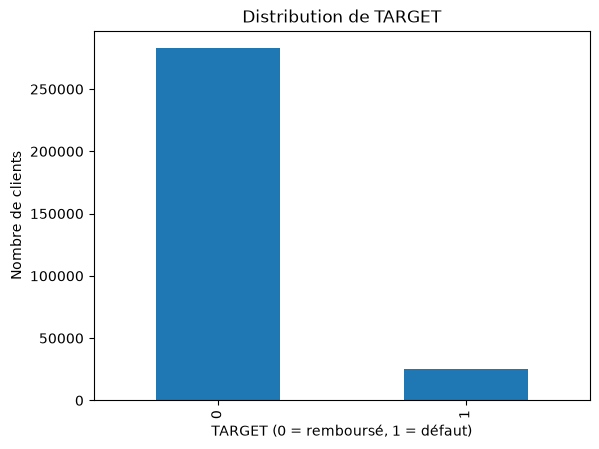

In [2]:
import matplotlib.pyplot as plt

# Comptage et proportions
print(app_train["TARGET"].value_counts())
print()
print(app_train["TARGET"].value_counts(normalize=True))

# Visualisation
app_train["TARGET"].value_counts().plot(kind="bar", title="Distribution de TARGET")
plt.xlabel("TARGET (0 = remboursé, 1 = défaut)")
plt.ylabel("Nombre de clients")
plt.show()

### Analyse des valeurs manquantes

In [3]:
# Calcul du nombre et pourcentage de valeurs manquantes par colonne
valeurs_manquantes = app_train.isnull().sum().sort_values(ascending=False)
proportion_NaN = (valeurs_manquantes / len(app_train) * 100).round(2)

tableau_NaN = pd.DataFrame({
    "nb_valeurs_manquantes": valeurs_manquantes,
    "pourcentage": proportion_NaN
})

# On affiche seulement les colonnes concernées
tableau_NaN = tableau_NaN[tableau_NaN["nb_valeurs_manquantes"] > 0]

print(f"Nombre de colonnes avec des valeurs manquantes : {len(tableau_NaN)} sur {app_train.shape[1]}")
tableau_NaN.head(20)

Nombre de colonnes avec des valeurs manquantes : 67 sur 122


,nb_valeurs_manquantes,pourcentage
COMMONAREA_AVG,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_MEDI,214865,69.87
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


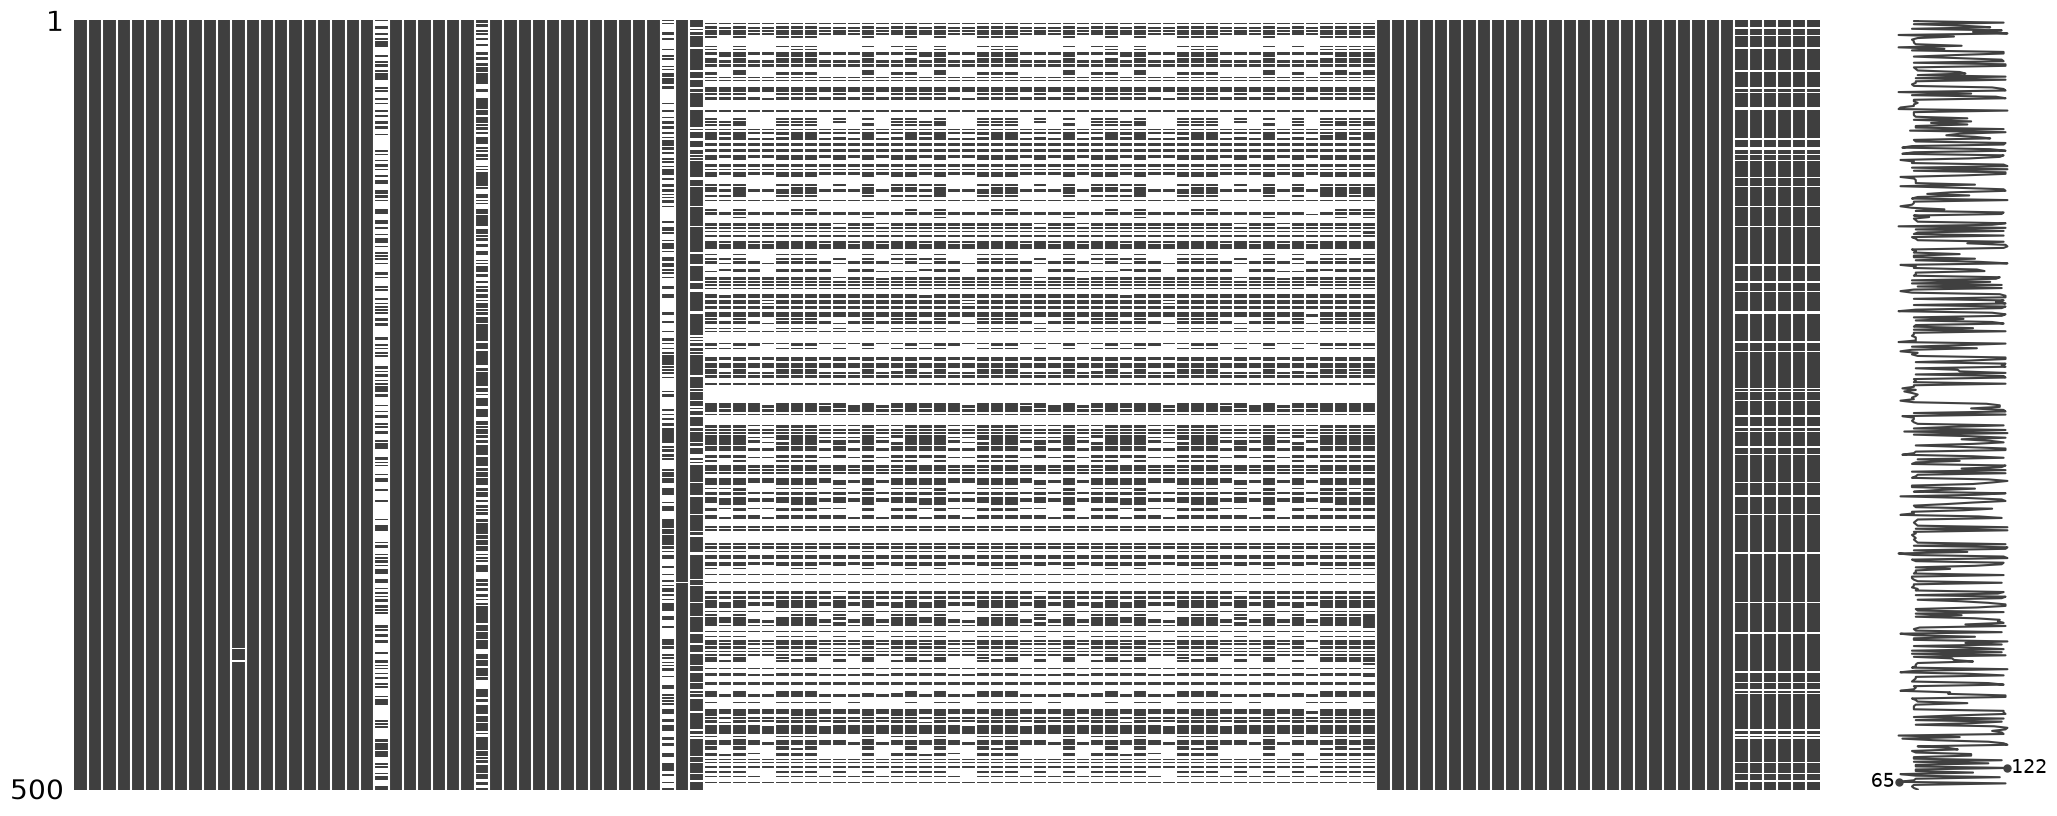

In [4]:
import missingno as msno

# Matrice de valeurs manquantes (sur un échantillon 500)
msno.matrix(app_train.sample(500))
plt.show()

### Analyse des variables numériques/catégorielles

In [5]:
# On sépare les colonnes selon leur type
colonnes_numeriques = app_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
colonnes_categorielles = app_train.select_dtypes(include=["object"]).columns.tolist()

print(f"Nombre de colonnes numériques : {len(colonnes_numeriques)}")
print(f"Nombre de colonnes catégorielles : {len(colonnes_categorielles)}")

Nombre de colonnes numériques : 106
Nombre de colonnes catégorielles : 16


C:\Users\yavas\AppData\Local\Temp\ipykernel_26180\1760323013.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colonnes_categorielles = app_train.select_dtypes(include=["object"]).columns.tolist()


#### Variables catégorielles

In [11]:
variables_categorielles = []

for colonne in colonnes_categorielles:
    freq_prop= (app_train[colonne].value_counts(dropna=False, normalize=True)*100).round(1).to_dict()
    freq_prop_format={k: f"{v}%" for k, v in freq_prop.items()}
    variables_categorielles.append({
        "variable": colonne,
        "nb_valeurs_uniques": app_train[colonne].nunique(),
        "nb_NaN": app_train[colonne].isnull().sum(),
        "frequences":freq_prop_format
    })

variables_categorielles = pd.DataFrame(variables_categorielles)
variables_categorielles

,variable,nb_valeurs_uniques,nb_NaN,frequences
0,NAME_CONTRACT_TYPE,2,0,"{'Cash loans': '90.5%', 'Revolving loans': '9...."
1,CODE_GENDER,3,0,"{'F': '65.8%', 'M': '34.2%', 'XNA': '0.0%'}"
2,FLAG_OWN_CAR,2,0,"{'N': '66.0%', 'Y': '34.0%'}"
3,FLAG_OWN_REALTY,2,0,"{'Y': '69.4%', 'N': '30.6%'}"
4,NAME_TYPE_SUITE,7,1292,"{'Unaccompanied': '80.8%', 'Family': '13.1%', ..."
5,NAME_INCOME_TYPE,8,0,"{'Working': '51.6%', 'Commercial associate': '..."
6,NAME_EDUCATION_TYPE,5,0,"{'Secondary / secondary special': '71.0%', 'Hi..."
7,NAME_FAMILY_STATUS,6,0,"{'Married': '63.9%', 'Single / not married': '..."
8,NAME_HOUSING_TYPE,6,0,"{'House / apartment': '88.7%', 'With parents':..."
9,OCCUPATION_TYPE,18,96391,"{nan: '31.3%', 'Laborers': '17.9%', 'Sales sta..."


In [32]:
# Détails
print("=== CODE_GENDER ===")
print(app_train["CODE_GENDER"].value_counts(dropna=False))
print()

print("=== ORGANIZATION_TYPE ===")
print(app_train["ORGANIZATION_TYPE"].value_counts(dropna=False).head(10))
print()

print("=== OCCUPATION_TYPE ===")
print(app_train["OCCUPATION_TYPE"].value_counts(dropna=False))
print()

print("=== NAME_FAMILY_STATUS ===")
print(app_train["NAME_FAMILY_STATUS"].value_counts(dropna=False))

=== CODE_GENDER ===
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

=== ORGANIZATION_TYPE ===
ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Name: count, dtype: int64

=== OCCUPATION_TYPE ===
OCCUPATION_TYPE
NaN                      96391
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Sec

#### Variables numériques

In [14]:
app_train[colonnes_numeriques].describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,1.000020e+05,189145.500000,278202.000000,367142.500000,4.562550e+05
TARGET,307511.0,0.080729,0.272419,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
CNT_CHILDREN,307511.0,0.417052,0.722121,0.000000e+00,0.000000,0.000000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,4.500000e+04,270000.000000,513531.000000,808650.000000,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,0.020868,0.013831,2.900000e-04,0.010006,0.018850,0.028663,7.250800e-02
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-2.522900e+04,-19682.000000,-15750.000000,-12413.000000,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-1.791200e+04,-2760.000000,-1213.000000,-289.000000,3.652430e+05


In [ ]:
# Détails

# AMT_INCOME_TOTAL : max trop élevé!! Afficher top 10 des revenus les plus élevés
print("=== Top 10 des revenus les plus élevés ===")
print(app_train.nlargest(10, "AMT_INCOME_TOTAL")[["SK_ID_CURR", "AMT_INCOME_TOTAL", "NAME_INCOME_TYPE", "TARGET"]])
print()

# AMT_REQ_CREDIT_BUREAU_QRT : max élevé ! Afficher top 10 des valeurs les plus élevées
print("=== Top 10 de AMT_REQ_CREDIT_BUREAU_QRT ===")
print(app_train.nlargest(10, "AMT_REQ_CREDIT_BUREAU_QRT")[["SK_ID_CURR", "AMT_REQ_CREDIT_BUREAU_QRT"]])

=== Top 10 des revenus les plus élevés ===
        SK_ID_CURR  AMT_INCOME_TOTAL      NAME_INCOME_TYPE  TARGET
12840       114967       117000000.0               Working       1
203693      336147        18000090.0  Commercial associate       0
246858      385674        13500000.0  Commercial associate       0
77768       190160         9000000.0               Working       0
131127      252084         6750000.0               Working       0
103006      219563         4500000.0               Working       0
187833      317748         4500000.0               Working       0
204564      337151         4500000.0               Working       0
287463      432980         4500000.0               Working       0
181698      310601         3950059.5  Commercial associate       0

=== Top 10 de AMT_REQ_CREDIT_BUREAU_QRT ===
        SK_ID_CURR  AMT_REQ_CREDIT_BUREAU_QRT
239474      377322                      261.0
253541      393383                       19.0
3770        104403                   

### Corrélation entre variables

In [20]:
import numpy as np

# Matrice de corrélation entre toutes les variables numériques
matrice_correlation = app_train[colonnes_numeriques].corr().abs()

# On ne garde que la moitié supérieure de la matrice (évite les doublons)
masque_superieur = np.triu(np.ones(matrice_correlation.shape), k=1).astype(bool)
paires_correlees = matrice_correlation.where(masque_superieur).stack().sort_values(ascending=False)

# On filtre seulement les paires avec une corrélation forte (seuil à 0.7)
seuil_correlation = 0.7
paires_fortement_correlees = paires_correlees[paires_correlees > seuil_correlation]

print(f"Nombre de paires avec une corrélation > {seuil_correlation} : {len(paires_fortement_correlees)}")
print()
print(paires_fortement_correlees)

Nombre de paires avec une corrélation > 0.7 : 127

DAYS_EMPLOYED                 FLAG_EMP_PHONE                  0.999755
YEARS_BUILD_AVG               YEARS_BUILD_MEDI                0.998495
OBS_30_CNT_SOCIAL_CIRCLE      OBS_60_CNT_SOCIAL_CIRCLE        0.998490
FLOORSMIN_AVG                 FLOORSMIN_MEDI                  0.997241
FLOORSMAX_AVG                 FLOORSMAX_MEDI                  0.997034
ENTRANCES_AVG                 ENTRANCES_MEDI                  0.996886
ELEVATORS_AVG                 ELEVATORS_MEDI                  0.996099
COMMONAREA_AVG                COMMONAREA_MEDI                 0.995978
LIVINGAREA_AVG                LIVINGAREA_MEDI                 0.995596
APARTMENTS_AVG                APARTMENTS_MEDI                 0.995081
BASEMENTAREA_AVG              BASEMENTAREA_MEDI               0.994317
LIVINGAPARTMENTS_AVG          LIVINGAPARTMENTS_MEDI           0.993825
YEARS_BEGINEXPLUATATION_AVG   YEARS_BEGINEXPLUATATION_MEDI    0.993825
LANDAREA_AVG              

### Corrélation avec TARGET

In [21]:
correlation_target = app_train[colonnes_numeriques].corr()["TARGET"]
correlation_target = correlation_target.drop("TARGET")

tableau_correlation_target = pd.DataFrame({
    "correlation": correlation_target,
    "force_correlation": correlation_target.abs()
}).sort_values("force_correlation", ascending=False)

tableau_correlation_target

,correlation,force_correlation
EXT_SOURCE_3,-0.178919,0.178919
EXT_SOURCE_2,-0.160472,0.160472
EXT_SOURCE_1,-0.155317,0.155317
DAYS_BIRTH,0.078239,0.078239
REGION_RATING_CLIENT_W_CITY,0.060893,0.060893
REGION_RATING_CLIENT,0.058899,0.058899
DAYS_LAST_PHONE_CHANGE,0.055218,0.055218
DAYS_ID_PUBLISH,0.051457,0.051457
REG_CITY_NOT_WORK_CITY,0.050994,0.050994
FLAG_EMP_PHONE,0.045982,0.045982


### Séléction des variables à supprimer

In [22]:
variables_a_supprimer = set()

for (var1, var2) in paires_fortement_correlees.index:
    # Si les deux variables sont encore présentes, on tranche
    if var1 not in variables_a_supprimer and var2 not in variables_a_supprimer:
        corr_var1 = abs(tableau_correlation_target.loc[var1, "correlation"])
        corr_var2 = abs(tableau_correlation_target.loc[var2, "correlation"])
        
        # On supprime celle qui a la plus faible corrélation avec TARGET
        if corr_var1 < corr_var2:
            variables_a_supprimer.add(var1)
        else:
            variables_a_supprimer.add(var2)

print(f"Nombre de variables à supprimer : {len(variables_a_supprimer)}")
print(variables_a_supprimer)

Nombre de variables à supprimer : 42
{'LIVINGAREA_AVG', 'AMT_ANNUITY', 'LIVINGAPARTMENTS_AVG', 'LIVE_CITY_NOT_WORK_CITY', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'LANDAREA_AVG', 'YEARS_BUILD_MODE', 'LIVE_REGION_NOT_WORK_REGION', 'DEF_60_CNT_SOCIAL_CIRCLE', 'YEARS_BEGINEXPLUATATION_MODE', 'TOTALAREA_MODE', 'REGION_RATING_CLIENT', 'NONLIVINGAREA_MEDI', 'LIVINGAREA_MEDI', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MEDI', 'FLOORSMIN_AVG', 'APARTMENTS_MODE', 'FLOORSMAX_MEDI', 'ELEVATORS_MODE', 'FLOORSMIN_MODE', 'CNT_FAM_MEMBERS', 'ENTRANCES_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAREA_MODE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'LIVINGAPARTMENTS_MODE', 'COMMONAREA_MODE', 'YEARS_BEGINEXPLUATATION_AVG', 'AMT_CREDIT', 'ENTRANCES_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'DAYS_EMPLOYED', 'FLOORSMIN_MEDI', 'ELEVATORS_MEDI', 'APARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'FLOORSMAX_MODE', 'APARTMENTS_AVG', 'BASEMENTAREA_MODE', 'BASEMENTAREA_MEDI'}


In [23]:
# Vérification détails sur 2 variables
for variable_cible in ["AMT_ANNUITY", "CNT_FAM_MEMBERS"]:
    print(f"=== Paires impliquant {variable_cible} ===")
    for (var1, var2) in paires_fortement_correlees.index:
        if var1 == variable_cible or var2 == variable_cible:
            autre_variable = var2 if var1 == variable_cible else var1
            corr_cible = tableau_correlation_target.loc[variable_cible, "correlation"]
            corr_autre = tableau_correlation_target.loc[autre_variable, "correlation"]
            corr_entre_elles = paires_fortement_correlees[(var1, var2)]
            print(f"  {variable_cible} (corr TARGET={corr_cible:.4f}) vs {autre_variable} (corr TARGET={corr_autre:.4f}) — corrélation entre elles: {corr_entre_elles:.4f}")
    print() 

=== Paires impliquant AMT_ANNUITY ===
  AMT_ANNUITY (corr TARGET=-0.0128) vs AMT_GOODS_PRICE (corr TARGET=-0.0396) — corrélation entre elles: 0.7751
  AMT_ANNUITY (corr TARGET=-0.0128) vs AMT_CREDIT (corr TARGET=-0.0304) — corrélation entre elles: 0.7701

=== Paires impliquant CNT_FAM_MEMBERS ===
  CNT_FAM_MEMBERS (corr TARGET=0.0093) vs CNT_CHILDREN (corr TARGET=0.0192) — corrélation entre elles: 0.8792



In [25]:
# Réajustement selon contexte métier

variables_a_supprimer.discard("DAYS_EMPLOYED")       # ancienneté professionnelle, plus riche que FLAG_EMP_PHONE qu'on supprimera ensuite
variables_a_supprimer.discard("AMT_CREDIT")          # montant du crédit accordé, cœur du métier
variables_a_supprimer.discard("AMT_ANNUITY")         # mensualité, reflète la durée du prêt
variables_a_supprimer.discard("CNT_FAM_MEMBERS")     # taille du foyer, reflète la capacité de remboursement en plus des personnes à charge
variables_a_supprimer.add("FLAG_EMP_PHONE")          

print(f"Nombre de variables à supprimer après ajustement métier : {len(variables_a_supprimer)}")
print(variables_a_supprimer)

Nombre de variables à supprimer après ajustement métier : 39
{'LIVINGAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVE_CITY_NOT_WORK_CITY', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'LANDAREA_AVG', 'YEARS_BUILD_MODE', 'LIVE_REGION_NOT_WORK_REGION', 'DEF_60_CNT_SOCIAL_CIRCLE', 'YEARS_BEGINEXPLUATATION_MODE', 'TOTALAREA_MODE', 'REGION_RATING_CLIENT', 'NONLIVINGAREA_MEDI', 'LIVINGAREA_MEDI', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MEDI', 'FLOORSMIN_AVG', 'FLAG_EMP_PHONE', 'APARTMENTS_MODE', 'FLOORSMAX_MEDI', 'ELEVATORS_MODE', 'FLOORSMIN_MODE', 'ENTRANCES_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAREA_MODE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'LIVINGAPARTMENTS_MODE', 'COMMONAREA_MODE', 'YEARS_BEGINEXPLUATATION_AVG', 'ENTRANCES_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'FLOORSMIN_MEDI', 'ELEVATORS_MEDI', 'APARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'FLOORSMAX_MODE', 'APARTMENTS_AVG', 'BASEMENTAREA_MODE', 'BASEMENTAREA_MEDI'}


### Suppression des variables redondantes

In [26]:
print("Dimensions avant suppression :", app_train.shape)

app_train = app_train.drop(columns=variables_a_supprimer)

print("Dimensions après suppression :", app_train.shape)

Dimensions avant suppression : (307511, 122)
Dimensions après suppression : (307511, 83)


### Nettoyage des données

#### Gestion des anomalies observés  

Anomalie 1

In [29]:
#  DAYS_EMPLOYED

# Vérifions les valeurs positives
valeurs_positives = app_train["DAYS_EMPLOYED"] > 0
print("Nombre de lignes avec DAYS_EMPLOYED positif :", valeurs_positives.sum())
print("Valeurs uniques parmi les positives :", app_train.loc[valeurs_positives, "DAYS_EMPLOYED"].unique())
print()


# Qui sont ces clients avec la valeur positive suspecte ?
masque_suspect = app_train["DAYS_EMPLOYED"] == 365243
print("Répartition de NAME_INCOME_TYPE pour ces lignes :")
print(app_train.loc[masque_suspect, "NAME_INCOME_TYPE"].value_counts())

Nombre de lignes avec DAYS_EMPLOYED positif : 55374
Valeurs uniques parmi les positives : [365243]

Répartition de NAME_INCOME_TYPE pour ces lignes :
NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64


Traitement  
365243 est un code pour "sans emploi", on le remplace par "NaN" pour ne pas fausser la variable numérique et on garde l'information via un indicateur binaire pour conserver cette information de façon fiable pour le modèle.(redondance avec NAME_INCOME_TYPE -Pensioner/Unemployed mais utile pour signaler au modèle que la future valeur imputée dans DAYS_EMPLOYED pour ces lignes est artificielle, plutôt qu'une vraie mesure d'ancienneté professionnelle)

In [30]:
# Création d'un indicateur avant de modifier la variable
app_train["FLAG_SANS_EMPLOI"] = (app_train["DAYS_EMPLOYED"] == 365243).astype(int)

# Remplacement du code 365243 par NaN
app_train["DAYS_EMPLOYED"] = app_train["DAYS_EMPLOYED"].replace(365243, np.nan)

# Vérification
print("Nombre de clients sans emploi :", app_train["FLAG_SANS_EMPLOI"].sum())
print(app_train["DAYS_EMPLOYED"].describe())

Nombre de clients sans emploi : 55374
count    252137.000000
mean      -2384.169325
std        2338.360162
min      -17912.000000
25%       -3175.000000
50%       -1648.000000
75%        -767.000000
max           0.000000
Name: DAYS_EMPLOYED, dtype: float64


Anomalie 2  
Présence négligeable de XNA/UNKNOWN dans CODE_GENDER et NAME_FAMILY_STATUS  
Traitement: suppression

In [33]:
print("Dimensions avant :", app_train.shape)

app_train = app_train[app_train["CODE_GENDER"] != "XNA"]
app_train = app_train[app_train["NAME_FAMILY_STATUS"] != "Unknown"]

print("Dimensions après :", app_train.shape)

Dimensions avant : (307511, 84)
Dimensions après : (307505, 84)


Anomalie 3  
Une ligne à 117 000 000 dans AMT_INCOME_TOTAL, avec un profil incohérent (salarié "Working", TARGET=1).  
Traitement: suppression car jugée comme probable erreur de saisie plutôt qu'une vraie valeur

In [34]:
print("Dimensions avant :", app_train.shape)

app_train = app_train[app_train["AMT_INCOME_TOTAL"] != app_train["AMT_INCOME_TOTAL"].max()]

print("Dimensions après :", app_train.shape)

Dimensions avant : (307505, 84)
Dimensions après : (307504, 84)


Anomalie 4  
Une ligne à 261 dans AMT_REQ_CREDIT_BUREAU_QRT, largement supérieure à toutes les autres valeurs observées (max ailleurs = 19).  
Traitement: suppression car probable erreur de saisie

In [35]:
print("Dimensions avant :", app_train.shape)

app_train = app_train[app_train["AMT_REQ_CREDIT_BUREAU_QRT"] != app_train["AMT_REQ_CREDIT_BUREAU_QRT"].max()]

print("Dimensions après :", app_train.shape)

Dimensions avant : (307504, 84)
Dimensions après : (307503, 84)


#### Gestion des valeurs manquantes

In [40]:
# Vue d'ensemble

valeurs_manquantes = app_train.isnull().sum().sort_values(ascending=False)
pourcentage_manquantes = (valeurs_manquantes / len(app_train) * 100).round(2)

tableau_manquantes = pd.DataFrame({
    "nb_valeurs_manquantes": valeurs_manquantes,
    "pourcentage_manquantes": pourcentage_manquantes
})

tableau_manquantes = tableau_manquantes[tableau_manquantes["nb_valeurs_manquantes"] > 0]
tableau_manquantes

,nb_valeurs_manquantes,pourcentage_manquantes
COMMONAREA_MEDI,214859,69.87
NONLIVINGAPARTMENTS_AVG,213509,69.43
FONDKAPREMONT_MODE,210290,68.39
YEARS_BUILD_MEDI,204483,66.50
OWN_CAR_AGE,202923,65.99
LANDAREA_MEDI,182585,59.38
BASEMENTAREA_AVG,179940,58.52
EXT_SOURCE_1,173375,56.38
NONLIVINGAREA_AVG,169678,55.18
ELEVATORS_AVG,163889,53.30


#### Encodage des variables catégorielles  
Approche inspirée du kernel jsaguiar : one-hot encoding avec pd.get_dummies, en traitant les NaN comme leur propre catégorie (dummy_na=True) plutôt que de les imputer arbitrairement.

In [43]:
def encodage_one_hot(df, nan_as_category=True):
    colonnes_avant = list(df.columns)
    colonnes_categorielles = df.select_dtypes(include=["object", "str"]).columns.tolist()
    df = pd.get_dummies(df, columns=colonnes_categorielles, dummy_na=nan_as_category)
    nouvelles_colonnes = [c for c in df.columns if c not in colonnes_avant]
    return df, nouvelles_colonnes

print("Dimensions avant encodage :", app_train.shape)

app_train, colonnes_encodees = encodage_one_hot(app_train, nan_as_category=True)

print("Dimensions après encodage :", app_train.shape)
print(f"Nombre de nouvelles colonnes créées : {len(colonnes_encodees)}")

Dimensions avant encodage : (307503, 84)
Dimensions après encodage : (307503, 222)
Nombre de nouvelles colonnes créées : 154


In [44]:
# Vérification

print("Types de colonnes après encodage :")
print(app_train.dtypes.value_counts())

Types de colonnes après encodage :
bool       154
int64       37
float64     31
Name: count, dtype: int64


#### Imputation des valeurs manquantes
Toutes les colonnes sont maintenant numériques après l'encodage. On applique une imputation par médiane sur l'ensemble du dataframe (hors identifiant et cible), approche inspirée du kernel de Koehrsen.

In [ ]:
from sklearn.impute import SimpleImputer

# On exclut SK_ID_CURR (identifiant) et TARGET (la cible) de l'imputation
colonnes_a_imputer = [col for col in app_train.columns if col not in ["SK_ID_CURR", "TARGET"]]

imputer = SimpleImputer(strategy="median")

print("Valeurs manquantes avant :", app_train[colonnes_a_imputer].isnull().sum().sum())

app_train[colonnes_a_imputer] = imputer.fit_transform(app_train[colonnes_a_imputer])

print("Valeurs manquantes après :", app_train[colonnes_a_imputer].isnull().sum().sum())

Valeurs manquantes avant : 2531526
Valeurs manquantes après : 0


#### Feature engineering


In [46]:
app_train["DAYS_EMPLOYED_PERC"] = app_train["DAYS_EMPLOYED"] / app_train["DAYS_BIRTH"]               #stabilité professionnelle relative à l'âge
app_train["INCOME_CREDIT_PERC"] = app_train["AMT_INCOME_TOTAL"] / app_train["AMT_CREDIT"]            #revenu par rapport au montant du crédit, plus c'est élevé-plus le crédit est petit donc moins risqué
app_train["INCOME_PER_PERSON"] = app_train["AMT_INCOME_TOTAL"] / app_train["CNT_FAM_MEMBERS"]        #revenu par tete
app_train["ANNUITY_INCOME_PERC"] = app_train["AMT_ANNUITY"] / app_train["AMT_INCOME_TOTAL"]          #part du revenu mensuel absorbée par la mensualité du crédit, taux d'endettement
app_train["PAYMENT_RATE"] = app_train["AMT_ANNUITY"] / app_train["AMT_CREDIT"]                       #mensualité par rapport au montant total du crédit, indicateur de la durée du pret

print("Dimensions après feature engineering :", app_train.shape)
app_train[["DAYS_EMPLOYED_PERC", "INCOME_CREDIT_PERC", "INCOME_PER_PERSON", "ANNUITY_INCOME_PERC", "PAYMENT_RATE"]].describe()

Dimensions après feature engineering : (307503, 227)


C:\Users\yavas\AppData\Local\Temp\ipykernel_26180\1033588791.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_train["DAYS_EMPLOYED_PERC"] = app_train["DAYS_EMPLOYED"] / app_train["DAYS_BIRTH"]               #stabilité professionnelle relative à l'âge
C:\Users\yavas\AppData\Local\Temp\ipykernel_26180\1033588791.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_train["INCOME_CREDIT_PERC"] = app_train["AMT_INCOME_TOTAL"] / app_train["AMT_CREDIT"]            #revenu par rapport au montant du crédit, plus c'est élevé-plu

,DAYS_EMPLOYED_PERC,INCOME_CREDIT_PERC,INCOME_PER_PERSON,ANNUITY_INCOME_PERC,PAYMENT_RATE
count,307503.000000,307503.000000,3.075030e+05,307503.000000,307503.000000
mean,0.142370,0.398993,9.297946e+04,0.180931,0.053696
std,0.124882,0.343268,7.317103e+04,0.094573,0.022482
min,-0.000000,0.011801,2.812500e+03,0.003333,0.016790
25%,0.066851,0.193800,4.725000e+04,0.114787,0.036900
50%,0.091035,0.306272,7.500000e+04,0.162833,0.050000
75%,0.191050,0.495376,1.125000e+05,0.229067,0.064045
max,0.728811,26.666800,6.750000e+06,1.875965,0.158114


# App_test

In [47]:
# Chargement de app_test brut
app_test = pd.read_csv("../donnees/brutes/application_test.csv")
print("Dimensions initiales :", app_test.shape)

# Suppression des colonnes redondantes (mêmes que app_train)
app_test = app_test.drop(columns=variables_a_supprimer)

# DAYS_EMPLOYED : anomalie 365243 -> NaN + flag
app_test["FLAG_SANS_EMPLOI"] = (app_test["DAYS_EMPLOYED"] == 365243).astype(int)
app_test["DAYS_EMPLOYED"] = app_test["DAYS_EMPLOYED"].replace(365243, np.nan)

# Encodage one-hot (même fonction que pour app_train)
app_test, _ = encodage_one_hot(app_test, nan_as_category=True)

print("Dimensions après nettoyage + encodage :", app_test.shape)

Dimensions initiales : (48744, 121)
Dimensions après nettoyage + encodage : (48744, 220)


In [49]:
# Alignement train/test
target_sauvegarde = app_train["TARGET"]

app_train, app_test = app_train.align(app_test, join="inner", axis=1)

app_train["TARGET"] = target_sauvegarde

print("Dimensions app_train :", app_train.shape)
print("Dimensions app_test :", app_test.shape)

Dimensions app_train : (307503, 221)
Dimensions app_test : (48744, 220)


C:\Users\yavas\AppData\Local\Temp\ipykernel_26180\955681786.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_train["TARGET"] = target_sauvegarde


In [51]:
from sklearn.impute import SimpleImputer

# Colonnes à imputer : toutes sauf TARGET (train) et SK_ID_CURR (identifiant)
colonnes_a_imputer = [col for col in app_train.columns if col not in ["TARGET", "SK_ID_CURR"]]

# On refait l'imputer sur les colonnes actuelles de app_train (post-alignement)
imputer = SimpleImputer(strategy="median")
imputer.fit(app_train[colonnes_a_imputer])

# Puis on applique à app_test
print("Valeurs manquantes avant :", app_test[colonnes_a_imputer].isnull().sum().sum())
app_test[colonnes_a_imputer] = imputer.transform(app_test[colonnes_a_imputer])
print("Valeurs manquantes après :", app_test[colonnes_a_imputer].isnull().sum().sum())

Valeurs manquantes avant : 382754
Valeurs manquantes après : 0


In [53]:
# feature engineering (post-alignement)
for df in [app_train, app_test]:
    df["DAYS_EMPLOYED_PERC"] = df["DAYS_EMPLOYED"] / df["DAYS_BIRTH"]
    df["INCOME_CREDIT_PERC"] = df["AMT_INCOME_TOTAL"] / df["AMT_CREDIT"]
    df["INCOME_PER_PERSON"] = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]
    df["ANNUITY_INCOME_PERC"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
    df["PAYMENT_RATE"] = df["AMT_ANNUITY"] / df["AMT_CREDIT"]

print("Dimensions finales app_train :", app_train.shape)
print("Dimensions finales app_test :", app_test.shape)

Dimensions finales app_train : (307503, 226)
Dimensions finales app_test : (48744, 225)


C:\Users\yavas\AppData\Local\Temp\ipykernel_26180\389091276.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["DAYS_EMPLOYED_PERC"] = df["DAYS_EMPLOYED"] / df["DAYS_BIRTH"]
C:\Users\yavas\AppData\Local\Temp\ipykernel_26180\389091276.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["INCOME_CREDIT_PERC"] = df["AMT_INCOME_TOTAL"] / df["AMT_CREDIT"]
C:\Users\yavas\AppData\Local\Temp\ipykernel_26180\389091276.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` man

In [54]:
# Sauvegarde des dataframes préparés, pour réutilisation
app_train.to_csv("../donnees/traitees/app_train_prepare.csv", index=False)
app_test.to_csv("../donnees/traitees/app_test_prepare.csv", index=False)

print("Fichiers sauvegardés avec succès.")

Fichiers sauvegardés avec succès.
